# Feeding America Map the Meal Gap (MMG) 2025 — EDA

**MinneMUDAC 2026 | Undergraduate Division**  
**Source:** `data/MMG2025_2019-2023_Data_To_Share_v2.xlsx`, worksheet `County`  

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (11, 6), 'figure.dpi': 110})

print('Python:', sys.version.split()[0])
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('Seaborn:', sns.__version__)

Python: 3.13.14
Pandas: 3.0.6
NumPy: 2.5.3
Seaborn: 0.13.2


## Step 2 — File paths and workbook sheets

In [ ]:
mmg_path = 'data/MMG2025_2019-2023_Data_To_Share_v2.xlsx'
assert Path(mmg_path).is_file(), f'Missing file: {Path(mmg_path).resolve()}'

with pd.ExcelFile(mmg_path, engine='openpyxl') as book:
    print('Worksheets:', book.sheet_names)

Worksheets: ['Read Me', 'County', 'Congressional District', 'State', 'Metro Area (50+ Only)', 'National (50+ Only)']


## Step 3 — Load County sheet and retain an unmodified copy

In [3]:
mmg_county_raw = pd.read_excel(
    mmg_path,
    sheet_name='County',
    dtype={'FIPS': 'string'},
    engine='openpyxl'
)
mmg_county = mmg_county_raw.copy()
print('All-US county-year rows and columns:', mmg_county.shape)
display(mmg_county.head())

All-US county-year rows and columns: (15872, 25)


,FIPS,State,"County, State",Year,Overall Food Insecurity Rate,Ratio (1 in X) Overall,# of Food Insecure Persons Overall,Food Insecurity Rate among Black Persons (all ethnicities),Food Insecurity Rate among Hispanic Persons (any race),"Food Insecurity Rate among White, non-Hispanic Persons",SNAP Threshold,% FI ≤ SNAP Threshold,% FI > SNAP Threshold,Child Food Insecurity Rate,# of Food Insecure Children,% food insecure children in HH w/ HH incomes below 185 FPL,% food insecure children in HH w/ HH incomes above 185 FPL,Cost Per Meal,Weighted weekly $ needed by FI,Weighted Annual Food Budget Shortfall,Rural-Urban Continuum Code (2013),Rural-Urban Continuum Code (2023),Census Region,Census Division,FNS Region
0,01001,AL,"Autauga County, Alabama",2019,0.157,6.000,"8,670.000",0.260,NaN,0.120,1.300,0.486,0.514,0.196,"2,590.000",0.690,0.310,3.000,16.880,"4,439,000.000",2.000,NaN,South,East South Central,Southeast
1,01001,AL,"Autauga County, Alabama",2020,0.145,7.000,"8,070.000",0.250,NaN,0.090,1.300,0.476,0.524,0.181,"2,380.000",0.710,0.290,3.220,17.090,"4,184,000.000",2.000,NaN,South,East South Central,Southeast
2,01001,AL,"Autauga County, Alabama",2021,0.133,8.000,"7,770.000",0.230,NaN,0.090,1.300,0.483,0.517,0.145,"2,000.000",0.680,0.320,3.600,20.990,"4,947,000.000",2.000,NaN,South,East South Central,Southeast
3,01001,AL,"Autauga County, Alabama",2022,0.151,7.000,"8,860.000",0.230,NaN,0.110,1.300,0.440,0.560,0.175,"2,410.000",0.680,0.320,4.010,24.860,"6,680,000.000",2.000,2.000,South,East South Central,Southeast
4,01001,AL,"Autauga County, Alabama",2023,0.151,7.000,"8,940.000",0.240,NaN,0.120,1.300,0.431,0.569,0.168,"2,350.000",0.660,0.340,3.640,22.720,"6,162,000.000",2.000,2.000,South,East South Central,Southeast


## Step 4 — Inspect schema and overview

In [4]:
schema = pd.DataFrame({
    'column': mmg_county.columns,
    'dtype': mmg_county.dtypes.astype(str).values,
    'missing': mmg_county.isna().sum().values,
    'missing_pct': (mmg_county.isna().mean() * 100).round(2).values
})
display(schema)
print('Year values:', sorted(mmg_county['Year'].dropna().unique().tolist()))
print('State abbreviations:', mmg_county['State'].nunique())
display(mmg_county.describe(include='number').T)

,column,dtype,missing,missing_pct
0,FIPS,string,0,0.000
1,State,str,0,0.000
2,"County, State",str,0,0.000
3,Year,int64,0,0.000
4,Overall Food Insecurity Rate,float64,79,0.500
5,Ratio (1 in X) Overall,float64,79,0.500
6,# of Food Insecure Persons Overall,float64,79,0.500
7,Food Insecurity Rate among Black Persons (all ...,float64,8440,53.180
8,Food Insecurity Rate among Hispanic Persons (a...,float64,6957,43.830
9,"Food Insecurity Rate among White, non-Hispanic...",float64,430,2.710


Year values: [2019, 2020, 2021, 2022, 2023]
State abbreviations: 52


,count,mean,std,min,25%,50%,75%,max
Year,"15,872.000","2,021.015",1.416,"2,019.000","2,020.000","2,021.000","2,022.000","2,023.000"
Overall Food Insecurity Rate,"15,793.000",0.134,0.039,0.022,0.107,0.132,0.159,0.324
Ratio (1 in X) Overall,"15,793.000",8.239,3.042,3.000,6.000,8.000,9.000,45.000
# of Food Insecure Persons Overall,"15,793.000","12,568.736","40,854.252",10.000,"1,480.000","3,600.000","8,960.000","1,440,800.000"
Food Insecurity Rate among Black Persons (all ethnicities),"7,432.000",0.242,0.071,0.000,0.200,0.240,0.290,0.650
Food Insecurity Rate among Hispanic Persons (any race),"8,915.000",0.195,0.051,0.030,0.160,0.190,0.230,0.580
"Food Insecurity Rate among White, non-Hispanic Persons","15,442.000",0.106,0.034,0.000,0.080,0.100,0.130,0.420
SNAP Threshold,"15,716.000",1.638,0.310,1.300,1.300,1.650,2.000,2.000
% FI ≤ SNAP Threshold,"15,715.000",0.605,0.145,0.038,0.506,0.598,0.704,1.000
% FI > SNAP Threshold,"15,715.000",0.395,0.145,0.000,0.296,0.402,0.494,0.962


## Step 5 — Select Minnesota and normalize county identifiers

In [5]:
mmg_mn = mmg_county.loc[
    mmg_county['State'].astype('string').str.strip().eq('MN')
].copy()

mmg_mn['FIPS'] = mmg_mn['FIPS'].astype('string').str.strip().str.zfill(5)
mmg_mn['Year'] = pd.to_numeric(mmg_mn['Year'], errors='coerce').astype('Int64')
mmg_mn['county_name'] = (
    mmg_mn['County, State']
    .astype('string')
    .str.replace(r',\s*Minnesota$', '', regex=True)
    .str.replace(r'\s+County$', '', regex=True)
)

print('Minnesota county-year rows:', len(mmg_mn))
print('Distinct Minnesota FIPS:', mmg_mn['FIPS'].nunique())
display(mmg_mn.groupby('Year').agg(rows=('FIPS','size'), counties=('FIPS','nunique')))
display(mmg_mn[['FIPS','county_name','Year']].head())

Minnesota county-year rows: 435
Distinct Minnesota FIPS: 87


,rows,counties
Year,,
2019,87,87
2020,87,87
2021,87,87
2022,87,87
2023,87,87


,FIPS,county_name,Year
6576,27001,Aitkin,2019
6577,27001,Aitkin,2020
6578,27001,Aitkin,2021
6579,27001,Aitkin,2022
6580,27001,Aitkin,2023


## Step 6 — Define the graded competition subset (2022–2023)

In [6]:
mmg_focus = mmg_mn.loc[mmg_mn['Year'].isin([2022, 2023])].copy()
assert mmg_focus.shape[0] == 174, 'Expected 87 counties for each of 2022 and 2023.'
assert mmg_focus.groupby('Year')['FIPS'].nunique().eq(87).all()

print('Main EDA: 2022 and 2023', mmg_focus.shape)
print('Optional context: 2019–2021', mmg_mn.loc[mmg_mn['Year'] < 2022].shape)
print('NOTE: 2024 is in the separate MMG2026 workbook.')

Main EDA: 2022 and 2023 (174, 26)
Optional context: 2019–2021 (261, 26)
NOTE: 2024 is in the separate MMG2026 workbook.


## Step 7 — Rename analytical variables using exact workbook headers

In [7]:
column_map = {
    'Overall Food Insecurity Rate': 'fi_rate',
    '# of Food Insecure Persons Overall': 'fi_people',
    'Child Food Insecurity Rate': 'child_fi_rate',
    '# of Food Insecure Children': 'fi_children',
    'SNAP Threshold': 'snap_threshold',
    '% FI ≤ SNAP Threshold': 'fi_below_snap_share',
    '% FI > SNAP Threshold': 'fi_above_snap_share',
    'Cost Per Meal': 'cost_per_meal',
    'Weighted weekly $ needed by FI': 'weekly_gap_per_person',
    'Weighted Annual Food Budget Shortfall': 'annual_budget_shortfall',
    'Rural-Urban Continuum Code (2023)': 'rucc_2023',
    'Food Insecurity Rate among Black Persons (all ethnicities)': 'fi_rate_black',
    'Food Insecurity Rate among Hispanic Persons (any race)': 'fi_rate_hispanic',
    'Food Insecurity Rate among White, non-Hispanic Persons': 'fi_rate_white_non_hispanic',
}

# A renamed COPY is convenient while the original workbook's columns stay untouched.
mmg_mn = mmg_mn.rename(columns=column_map)
mmg_focus = mmg_focus.rename(columns=column_map)

numeric_cols = list(column_map.values())
for frame in (mmg_mn, mmg_focus):
    for col in numeric_cols:
        frame[col] = pd.to_numeric(frame[col], errors='coerce')

display(mmg_focus[['FIPS', 'county_name', 'Year', 'fi_rate', 'fi_people', 'child_fi_rate']].head())

,FIPS,county_name,Year,fi_rate,fi_people,child_fi_rate
6579,27001,Aitkin,2022,0.130,"2,060.000",0.199
6580,27001,Aitkin,2023,0.137,"2,190.000",0.204
6584,27003,Anoka,2022,0.072,"26,300.000",0.126
6585,27003,Anoka,2023,0.085,"31,330.000",0.133
6589,27005,Becker,2022,0.107,"3,780.000",0.165


## Step 8 — Quality checks: duplicates, uniqueness, completeness

Exact duplicate Minnesota rows: 0
Repeated FIPS/year keys: 0
Missing year or FIPS: {'Year': 0, 'FIPS': 0}


,missing_n,missing_pct
fi_rate,0,0.000
fi_people,0,0.000
child_fi_rate,0,0.000
fi_children,0,0.000
fi_below_snap_share,0,0.000
fi_above_snap_share,0,0.000
cost_per_meal,0,0.000
annual_budget_shortfall,0,0.000


,fi_rate_black,fi_rate_hispanic,fi_rate_white_non_hispanic
Year,,,
2019,24,52,87
2020,25,52,87
2021,25,55,87
2022,24,52,87
2023,24,54,87


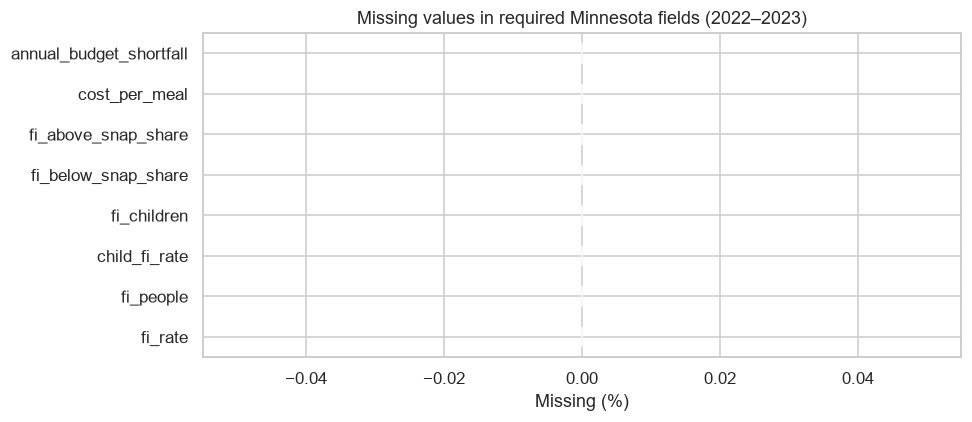

In [8]:
print('Exact duplicate Minnesota rows:', mmg_mn.duplicated().sum())
print('Repeated FIPS/year keys:', mmg_mn.duplicated(['FIPS','Year']).sum())
print('Missing year or FIPS:', mmg_mn[['Year','FIPS']].isna().sum().to_dict())

core_cols = ['fi_rate', 'fi_people', 'child_fi_rate', 'fi_children',
             'fi_below_snap_share', 'fi_above_snap_share',
             'cost_per_meal', 'annual_budget_shortfall']
missing = pd.DataFrame({
    'missing_n': mmg_focus[core_cols].isna().sum(),
    'missing_pct': 100 * mmg_focus[core_cols].isna().mean()
}).sort_values('missing_pct', ascending=False)
display(missing.round(2))

subgroup_cols = ['fi_rate_black','fi_rate_hispanic','fi_rate_white_non_hispanic']
display(mmg_mn.groupby('Year')[subgroup_cols].apply(lambda x: x.notna().sum()))

plt.figure(figsize=(9, 4))
missing['missing_pct'].sort_values().plot.barh(color='steelblue')
plt.title('Missing values in required Minnesota fields (2022–2023)')
plt.xlabel('Missing (%)')
plt.tight_layout()
plt.show()

## Step 9 — Numeric validation and complement checks

In [9]:
rate_fields = ['fi_rate', 'child_fi_rate', 'fi_below_snap_share', 'fi_above_snap_share',
               'fi_rate_black', 'fi_rate_hispanic', 'fi_rate_white_non_hispanic']
for col in rate_fields:
    valid = mmg_focus[col].dropna()
    bad = (~valid.between(0, 1)).sum()
    print(f'{col}: {bad} entries outside [0,1]')

for col in ['fi_people', 'fi_children', 'cost_per_meal',
            'weekly_gap_per_person', 'annual_budget_shortfall']:
    print(f'{col}: {(mmg_focus[col].dropna() < 0).sum()} negative entries')

share_sum = mmg_focus['fi_below_snap_share'] + mmg_focus['fi_above_snap_share']
print('SNAP-share pairs outside 1 ± 0.01:',
      ((share_sum - 1).abs() > .01).sum())
print('Records where child FI count exceeds overall FI count:',
      (mmg_focus['fi_children'] > mmg_focus['fi_people']).sum())

# Flags describe potential problems; do not automatically drop modeled estimates.

fi_rate: 0 entries outside [0,1]
child_fi_rate: 0 entries outside [0,1]
fi_below_snap_share: 0 entries outside [0,1]
fi_above_snap_share: 0 entries outside [0,1]
fi_rate_black: 0 entries outside [0,1]
fi_rate_hispanic: 0 entries outside [0,1]
fi_rate_white_non_hispanic: 0 entries outside [0,1]
fi_people: 0 negative entries
fi_children: 0 negative entries
cost_per_meal: 0 negative entries
weekly_gap_per_person: 0 negative entries
annual_budget_shortfall: 0 negative entries
SNAP-share pairs outside 1 ± 0.01: 0
Records where child FI count exceeds overall FI count: 0


## Step 10 — Year-by-year summary (counts versus rates)

In [10]:
annual_summary = mmg_mn.groupby('Year').agg(
    county_n=('FIPS','nunique'),
    county_rate_mean=('fi_rate','mean'),
    county_rate_median=('fi_rate','median'),
    county_rate_min=('fi_rate','min'),
    county_rate_max=('fi_rate','max'),
    estimated_people_sum=('fi_people','sum'),
    estimated_children_sum=('fi_children','sum')
)
display(annual_summary)

# WARNING: mean county rate is unweighted; sum of county FI estimates
# is NOT Feeding America's independently calculated state estimate.

,county_n,county_rate_mean,county_rate_median,county_rate_min,county_rate_max,estimated_people_sum,estimated_children_sum
Year,,,,,,,
2019,87,0.088,0.089,0.045,0.150,"432,940.000","154,190.000"
2020,87,0.078,0.074,0.036,0.161,"403,550.000","148,950.000"
2021,87,0.069,0.069,0.031,0.130,"342,640.000","110,000.000"
2022,87,0.100,0.100,0.060,0.157,"509,450.000","180,370.000"
2023,87,0.110,0.111,0.070,0.165,"581,270.000","187,320.000"


## Step 11 — Rate distributions: 2022 versus 2023

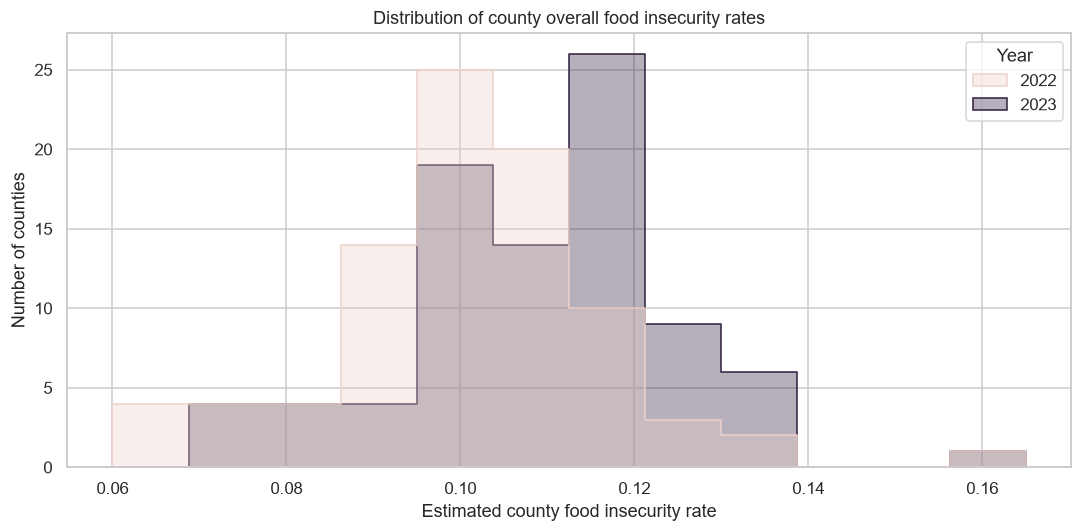

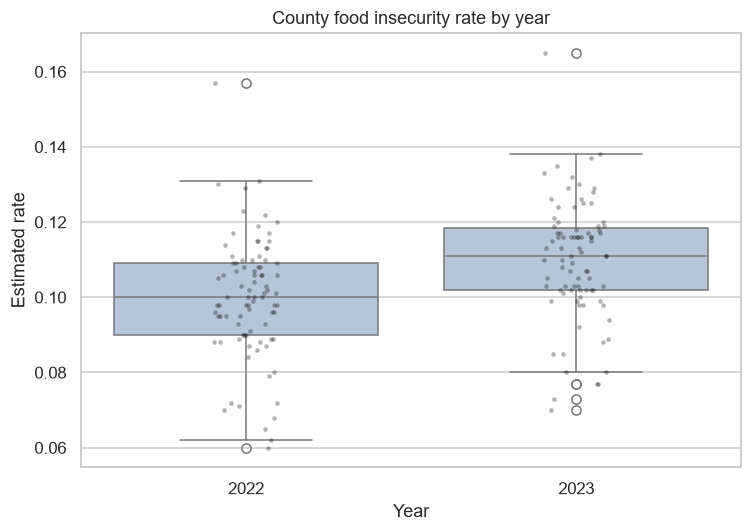

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=mmg_focus, x='fi_rate', hue='Year', bins=12,
             common_norm=False, element='step', alpha=.35)
plt.title('Distribution of county overall food insecurity rates')
plt.xlabel('Estimated county food insecurity rate')
plt.ylabel('Number of counties')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=mmg_focus, x='Year', y='fi_rate', color='lightsteelblue')
sns.stripplot(data=mmg_focus, x='Year', y='fi_rate', color='black', alpha=.3, size=3)
plt.title('County food insecurity rate by year')
plt.ylabel('Estimated rate')
plt.tight_layout()
plt.show()

## Step 12 — Highest and lowest county rates, 2023

Highest 10 county rates:


,county_name,FIPS,fi_rate,fi_people
6795,Mahnomen,27087,0.165,890.000
6595,Beltrami,27007,0.138,"6,390.000"
6580,Aitkin,27001,0.137,"2,190.000"
6650,Clearwater,27029,0.135,"1,160.000"
6730,Itasca,27061,0.133,"6,010.000"
6660,Cottonwood,27033,0.132,"1,510.000"
6635,Chippewa,27023,0.130,"1,610.000"
6755,Koochiching,27071,0.129,"1,540.000"
6975,Wadena,27159,0.129,"1,820.000"
6815,Mille Lacs,27095,0.128,"3,440.000"


Lowest 10 county rates:


,county_name,FIPS,fi_rate,fi_people
6925,Scott,27139,0.070,"10,640.000"
6625,Carver,27019,0.073,"7,930.000"
6985,Washington,27163,0.077,"21,010.000"
7005,Wright,27171,0.077,"11,210.000"
6675,Dodge,27039,0.080,"1,690.000"
6930,Sherburne,27141,0.080,"7,900.000"
6585,Anoka,27003,0.085,"31,330.000"
6670,Dakota,27037,0.085,"37,370.000"
6640,Chisago,27025,0.088,"5,030.000"
6715,Houston,27055,0.089,"1,670.000"


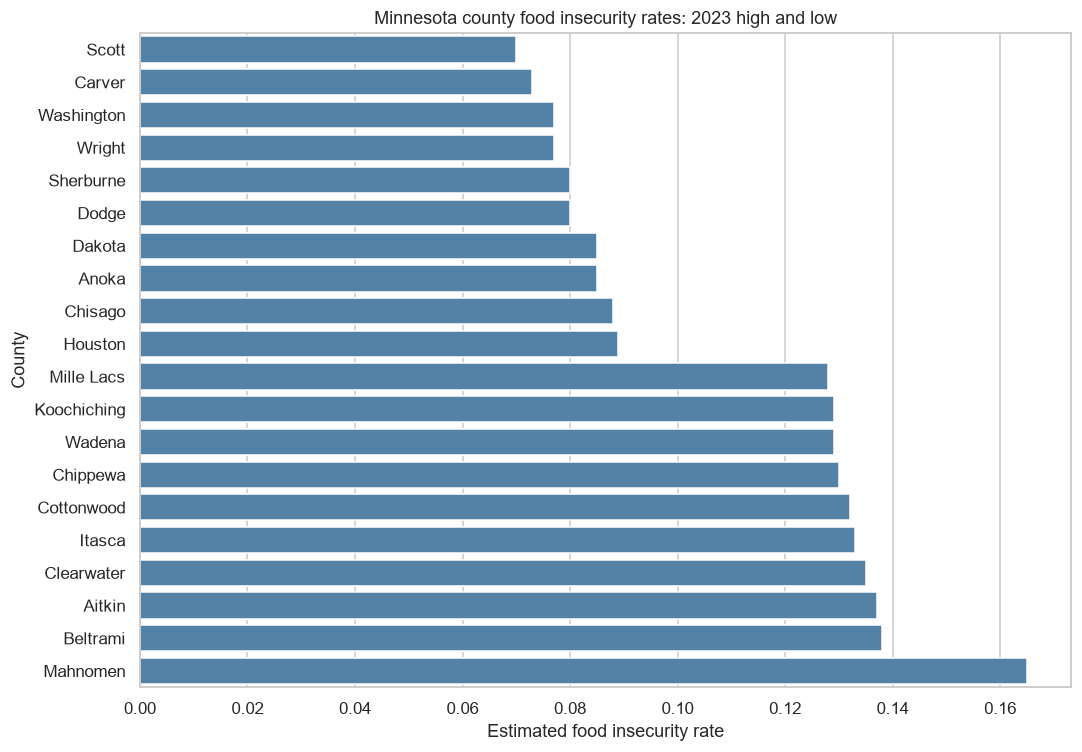

In [12]:
y2023 = mmg_focus.loc[mmg_focus['Year'] == 2023].copy()
print('Highest 10 county rates:')
display(y2023.nlargest(10,'fi_rate')[[
    'county_name','FIPS','fi_rate','fi_people'
]])
print('Lowest 10 county rates:')
display(y2023.nsmallest(10,'fi_rate')[[
    'county_name','FIPS','fi_rate','fi_people'
]])

plot_df = pd.concat([y2023.nlargest(10,'fi_rate'),y2023.nsmallest(10,'fi_rate')])
plot_df = plot_df.drop_duplicates('FIPS').sort_values('fi_rate')
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x='fi_rate', y='county_name', color='steelblue')
plt.title('Minnesota county food insecurity rates: 2023 high and low')
plt.xlabel('Estimated food insecurity rate')
plt.ylabel('County')
plt.tight_layout()
plt.show()

## Step 13 — Rate versus number: why county size matters

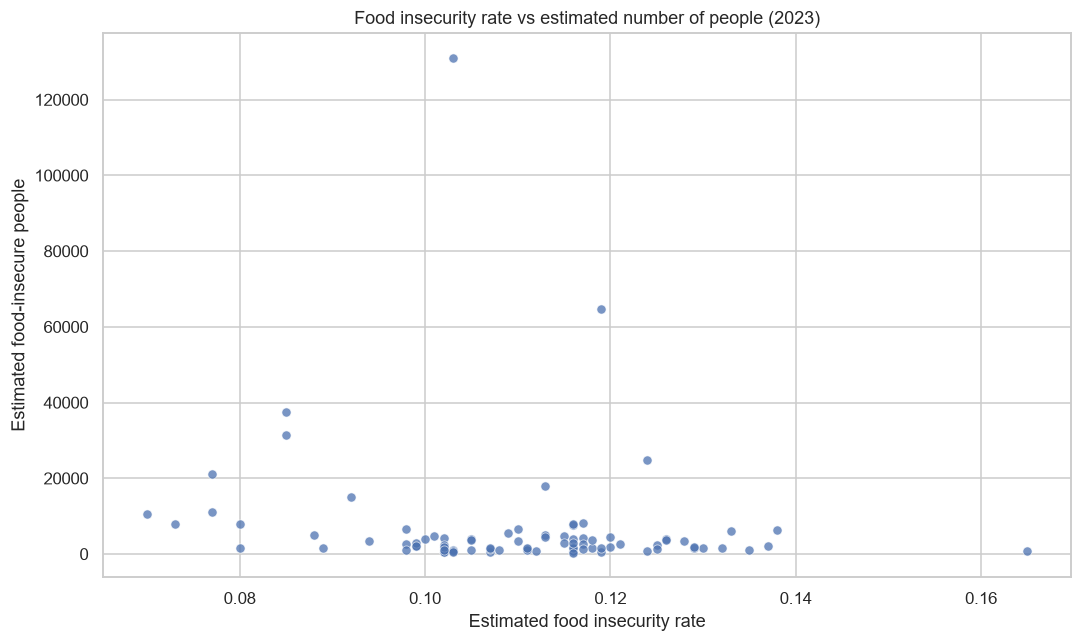

Top counties by estimated number of food-insecure people:


,county_name,fi_rate,fi_people
6710,Hennepin,0.103,"131,040.000"
6885,Ramsey,0.119,"64,830.000"
6670,Dakota,0.085,"37,370.000"
6585,Anoka,0.085,"31,330.000"
6920,St. Louis,0.124,"24,820.000"
6985,Washington,0.077,"21,010.000"
6940,Stearns,0.113,"18,080.000"
6850,Olmsted,0.092,"15,090.000"
7005,Wright,0.077,"11,210.000"
6925,Scott,0.070,"10,640.000"


In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=y2023, x='fi_rate', y='fi_people', alpha=.75)
plt.title('Food insecurity rate vs estimated number of people (2023)')
plt.xlabel('Estimated food insecurity rate')
plt.ylabel('Estimated food-insecure people')
plt.tight_layout()
plt.show()

print('Top counties by estimated number of food-insecure people:')
display(y2023.nlargest(10,'fi_people')[['county_name','fi_rate','fi_people']])

# Rankings by rate and by estimated number answer different questions.

## Step 14 — Year-over-year county changes (2022 to 2023)

Largest positive modeled changes (percentage points):


,Year,2022,2023,change_pp
FIPS,county_name,,,
27127,Redwood,0.096,0.116,2.000
27033,Cottonwood,0.114,0.132,1.800
27155,Traverse,0.098,0.116,1.800
27023,Chippewa,0.113,0.130,1.700
27031,Cook,0.100,0.116,1.600
27053,Hennepin,0.087,0.103,1.600
27009,Benton,0.100,0.115,1.500
27105,Nobles,0.106,0.121,1.500
27143,Sibley,0.096,0.111,1.500


Largest negative modeled changes (percentage points):


,Year,2022,2023,change_pp
FIPS,county_name,,,
27077,Lake of the Woods,0.103,0.102,-0.100
27075,Lake,0.110,0.111,0.100
27125,Red Lake,0.101,0.103,0.200
27069,Kittson,0.098,0.102,0.400
27029,Clearwater,0.131,0.135,0.400
27017,Carlton,0.115,0.120,0.500
27055,Houston,0.084,0.089,0.500
27073,Lac qui Parle,0.098,0.103,0.500
27173,Yellow Medicine,0.097,0.102,0.500


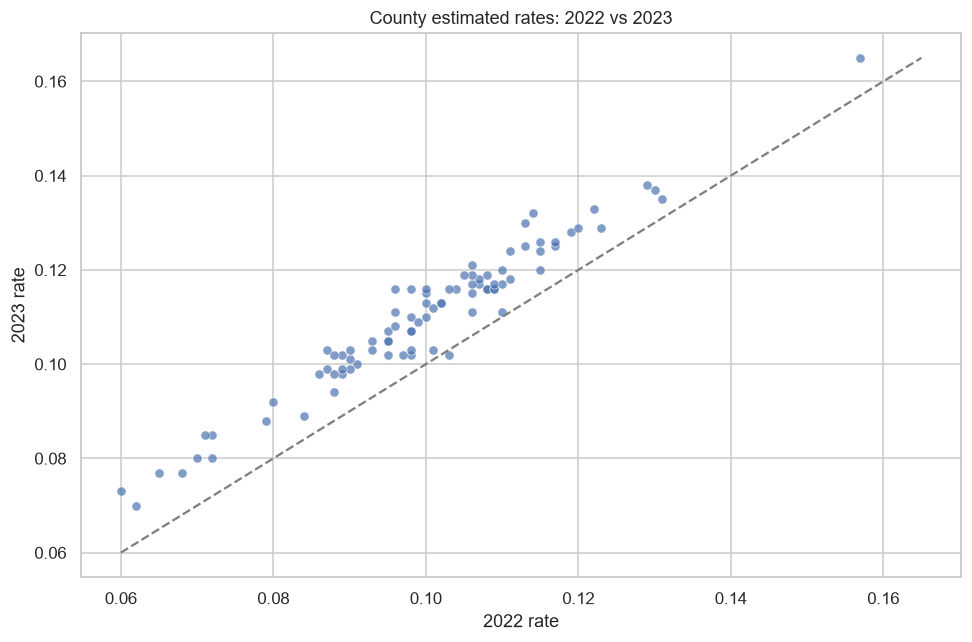

In [14]:
rate_wide = mmg_focus.pivot(index=['FIPS','county_name'],
                                columns='Year', values='fi_rate')
rate_wide['change_pp'] = 100 * (rate_wide[2023] - rate_wide[2022])
print('Largest positive modeled changes (percentage points):')
display(rate_wide.nlargest(10,'change_pp'))
print('Largest negative modeled changes (percentage points):')
display(rate_wide.nsmallest(10,'change_pp'))

plt.figure(figsize=(9, 6))
sns.scatterplot(x=rate_wide[2022], y=rate_wide[2023], alpha=.7)
low = min(rate_wide[2022].min(), rate_wide[2023].min())
high = max(rate_wide[2022].max(), rate_wide[2023].max())
plt.plot([low,high],[low,high],linestyle='--',color='gray')
plt.title('County estimated rates: 2022 vs 2023')
plt.xlabel('2022 rate')
plt.ylabel('2023 rate')
plt.tight_layout()
plt.show()

# MMG warns that many small changes in modeled county estimates
# may not be statistically meaningful. Do not label these as proven changes.

## Step 15 — Child food insecurity

,overall_rate_median,child_rate_median,estimated_children
Year,,,
2022,0.100,0.147,"180,370.000"
2023,0.111,0.151,"187,320.000"


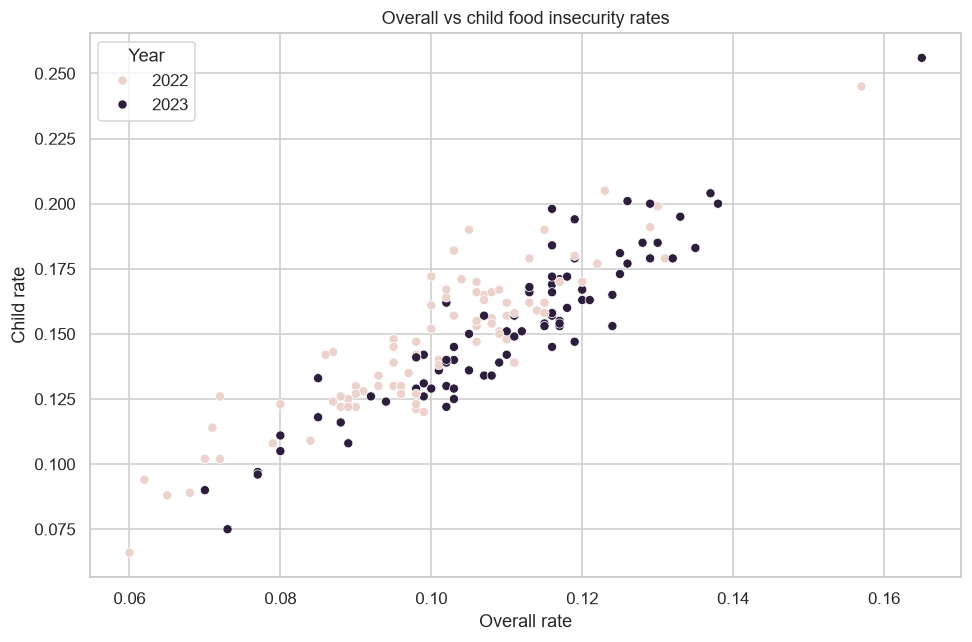

In [15]:
child_summary = mmg_focus.groupby('Year').agg(
    overall_rate_median=('fi_rate','median'),
    child_rate_median=('child_fi_rate','median'),
    estimated_children=('fi_children','sum')
)
display(child_summary)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=mmg_focus, x='fi_rate', y='child_fi_rate', hue='Year')
plt.title('Overall vs child food insecurity rates')
plt.xlabel('Overall rate')
plt.ylabel('Child rate')
plt.tight_layout()
plt.show()

## Step 16 — Income shares around SNAP threshold

snap_threshold             fi_below_snap_share              \
             median   min   max              median   min   max   
Year                                                              
2022          2.000 2.000 2.000               0.714 0.381 0.955   
2023          2.000 2.000 2.000               0.660 0.360 0.899   

     fi_above_snap_share              
                  median   min   max  
Year                                  
2022               0.286 0.045 0.619  
2023               0.340 0.101 0.640

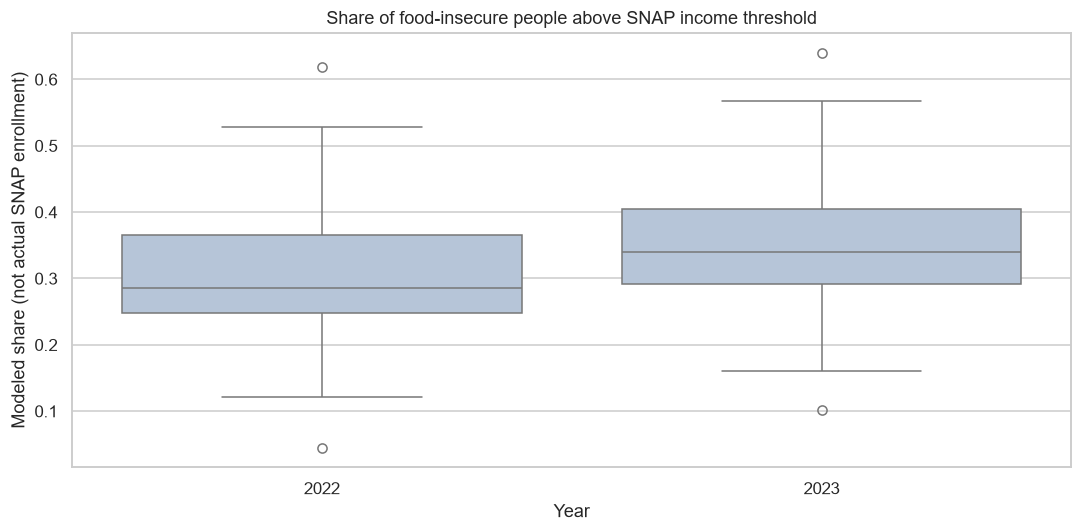

In [16]:
snap_summary = mmg_focus.groupby('Year')[
    ['snap_threshold','fi_below_snap_share','fi_above_snap_share']
].agg(['median','min','max'])
display(snap_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=mmg_focus, x='Year', y='fi_above_snap_share', color='lightsteelblue')
plt.title('Share of food-insecure people above SNAP income threshold')
plt.ylabel('Modeled share (not actual SNAP enrollment)')
plt.tight_layout()
plt.show()

# 'SNAP Threshold' is an income threshold expressed relative to FPL,
# NOT a participation/enrollment rate or dollars of benefits.

## Step 17 — Food affordability: view meal costs without misleading comparisons

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2022,87.000,4.181,0.315,3.670,3.990,4.100,4.350,5.190
2023,87.000,3.725,0.302,3.230,3.535,3.670,3.830,4.910


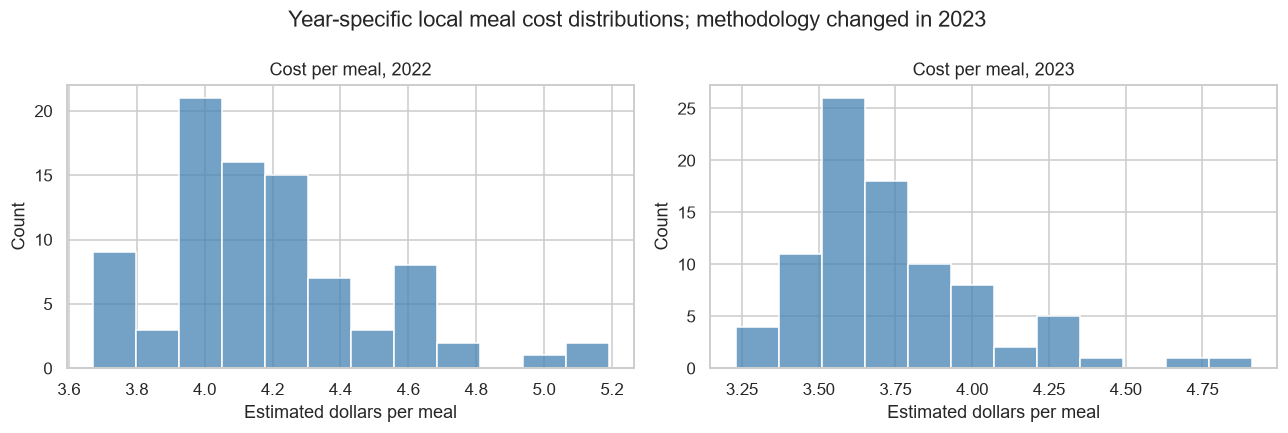

2023 counties with highest estimated cost per meal:


,county_name,cost_per_meal,fi_rate
6640,Chisago,4.910,0.088
6625,Carver,4.690,0.073
6710,Hennepin,4.440,0.103
6775,Le Sueur,4.320,0.099
6970,Wabasha,4.280,0.099
6690,Fillmore,4.270,0.099
6835,Nicollet,4.230,0.105
6885,Ramsey,4.220,0.119
6600,Benton,4.110,0.115
6985,Washington,4.070,0.077


In [17]:
display(mmg_focus.groupby('Year')['cost_per_meal'].describe())

# The 2023 MEAL COST method changed: compare COUNTIES WITHIN 2023;
# do NOT interpret a 2022-vs-2023 change as price inflation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
for ax, year in zip(axes, [2022, 2023]):
    subset = mmg_focus.loc[mmg_focus['Year'] == year]
    sns.histplot(data=subset, x='cost_per_meal', bins=12, ax=ax, color='steelblue')
    ax.set_title(f'Cost per meal, {year}')
    ax.set_xlabel('Estimated dollars per meal')
plt.suptitle('Year-specific local meal cost distributions; methodology changed in 2023')
plt.tight_layout()
plt.show()

print('2023 counties with highest estimated cost per meal:')
display(y2023.nlargest(10,'cost_per_meal')[['county_name','cost_per_meal','fi_rate']])

## Step 18 — Annual food budget shortfalls (also methodology-sensitive)

2023 top annual budget shortfalls by county:


,county_name,annual_budget_shortfall,fi_people
6710,Hennepin,"110,358,000.000","131,040.000"
6885,Ramsey,"51,819,000.000","64,830.000"
6670,Dakota,"28,430,000.000","37,370.000"
6585,Anoka,"22,770,000.000","31,330.000"
6920,St. Louis,"17,650,000.000","24,820.000"
6985,Washington,"16,190,000.000","21,010.000"
6940,Stearns,"12,392,000.000","18,080.000"
6850,Olmsted,"10,952,000.000","15,090.000"
7005,Wright,"8,626,000.000","11,210.000"
6925,Scott,"8,177,000.000","10,640.000"


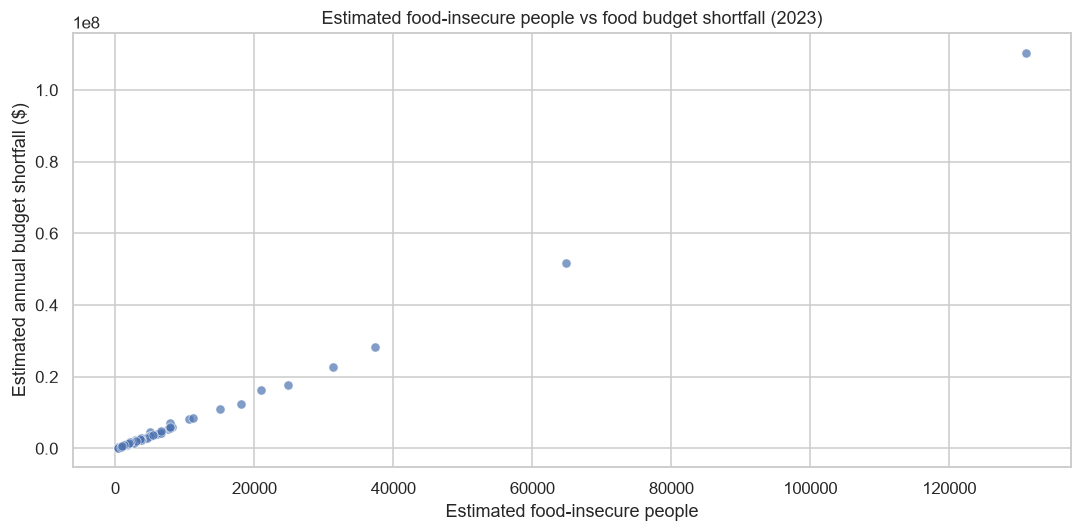

In [18]:
print('2023 top annual budget shortfalls by county:')
display(y2023.nlargest(10,'annual_budget_shortfall')[[
    'county_name', 'annual_budget_shortfall', 'fi_people'
]])

plt.figure(figsize=(10, 5))
sns.scatterplot(data=y2023, x='fi_people', y='annual_budget_shortfall', alpha=.7)
plt.title('Estimated food-insecure people vs food budget shortfall (2023)')
plt.xlabel('Estimated food-insecure people')
plt.ylabel('Estimated annual budget shortfall ($)')
plt.tight_layout()
plt.show()

# Do not interpret changes between 2022 and 2023 as a like-for-like
# shortfall growth rate: Feeding America changed the method in 2023.

## Step 19 — Urban/rural context (2023 RUCC)

County-years by metro classification:


metro_status,Metro (RUCC 1–3),Nonmetro (RUCC 4–9)
Year,,
2022,27,60
2023,27,60


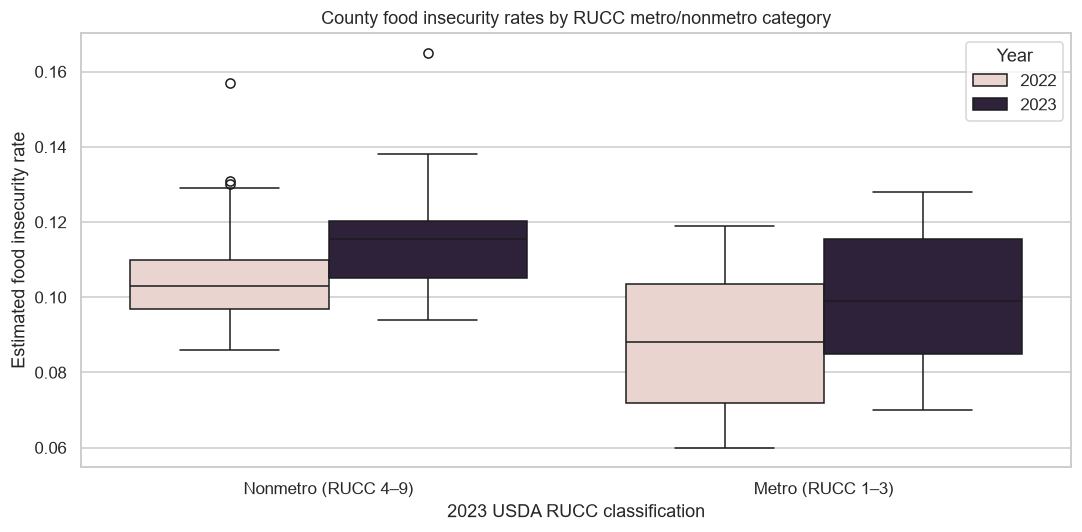

In [19]:
# The 2023 RUCC column is populated in 2022 and 2023 records.
mmg_focus['rucc_2023'] = mmg_focus['rucc_2023'].astype('Int64')
mmg_focus['metro_status'] = pd.Series(pd.NA, index=mmg_focus.index, dtype='string')
mmg_focus.loc[mmg_focus['rucc_2023'].between(1,3), 'metro_status'] = 'Metro (RUCC 1–3)'
mmg_focus.loc[mmg_focus['rucc_2023'].between(4,9), 'metro_status'] = 'Nonmetro (RUCC 4–9)'

print('County-years by metro classification:')
display(pd.crosstab(mmg_focus['Year'], mmg_focus['metro_status'], dropna=False))

plt.figure(figsize=(10, 5))
sns.boxplot(data=mmg_focus, x='metro_status', y='fi_rate', hue='Year')
plt.title('County food insecurity rates by RUCC metro/nonmetro category')
plt.xlabel('2023 USDA RUCC classification')
plt.ylabel('Estimated food insecurity rate')
plt.tight_layout()
plt.show()

# RUCC classification is not itself a direct measure of travel time
# or actual proximity to an active food shelf.

## Step 20 — Subgroup missingness and cautious exploratory plots

,Black persons (all ethnicities),Hispanic persons (any race),White non-Hispanic persons
Year,,,
2022,27.600,59.800,100.000
2023,27.600,62.100,100.000


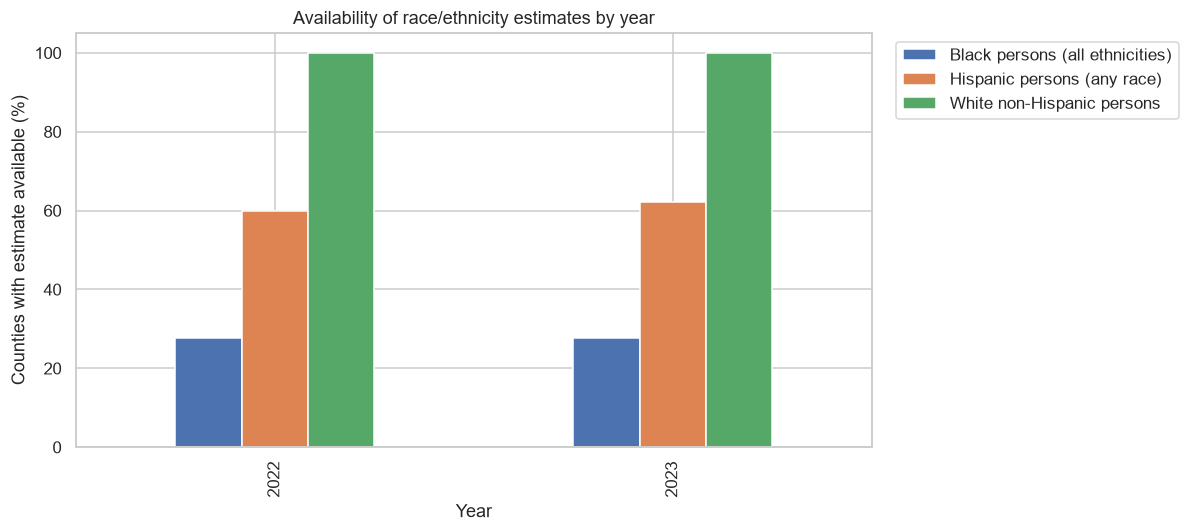

In [20]:
subgroup_names = {
    'fi_rate_black': 'Black persons (all ethnicities)',
    'fi_rate_hispanic': 'Hispanic persons (any race)',
    'fi_rate_white_non_hispanic': 'White non-Hispanic persons'
}
coverage = pd.DataFrame({
    name: mmg_focus.groupby('Year')[field].apply(lambda s: 100*s.notna().mean())
    for field,name in subgroup_names.items()
})
display(coverage.round(1))

coverage.plot(kind='bar', figsize=(11,5))
plt.title('Availability of race/ethnicity estimates by year')
plt.ylabel('Counties with estimate available (%)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout()
plt.show()

# Never fill unavailable estimates with zero or infer subgroup rates
# for counties where Feeding America does not publish them.

## Step 21 — Exploratory correlations for 2023

,fi_rate,fi_people,child_fi_rate,fi_children,fi_above_snap_share,cost_per_meal,annual_budget_shortfall
fi_rate,1.000,-0.180,0.900,-0.160,-0.660,-0.490,-0.200
fi_people,-0.180,1.000,-0.140,0.990,0.340,0.470,1.000
child_fi_rate,0.900,-0.140,1.000,-0.100,-0.660,-0.380,-0.160
fi_children,-0.160,0.990,-0.100,1.000,0.310,0.450,0.990
fi_above_snap_share,-0.660,0.340,-0.660,0.310,1.000,0.450,0.370
cost_per_meal,-0.490,0.470,-0.380,0.450,0.450,1.000,0.510
annual_budget_shortfall,-0.200,1.000,-0.160,0.990,0.370,0.510,1.000


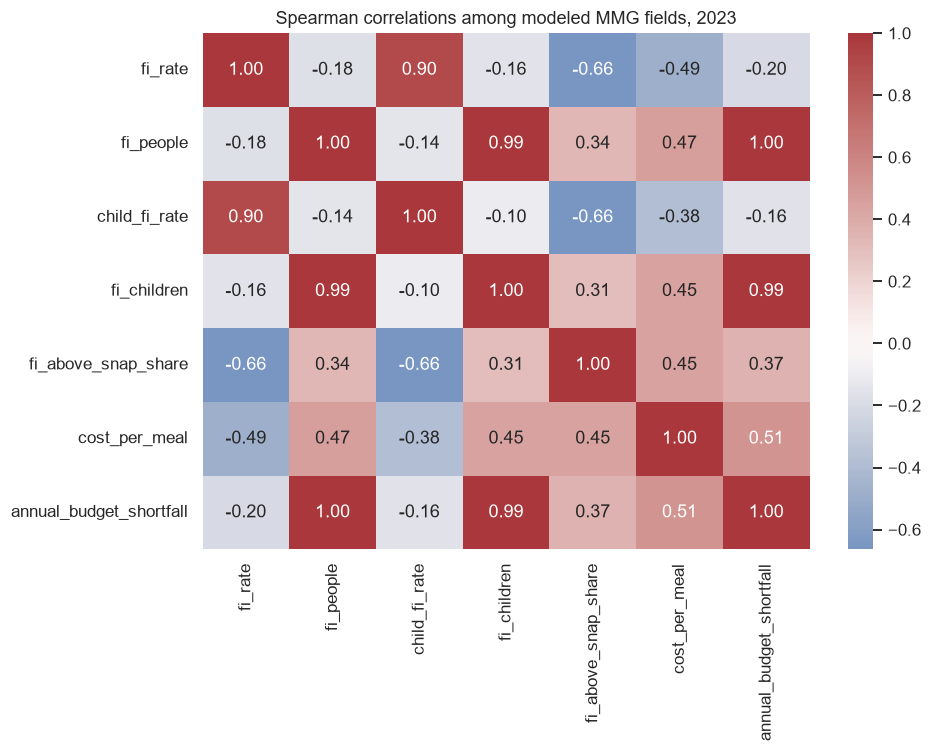

In [21]:
corr_cols = [
    'fi_rate','fi_people','child_fi_rate','fi_children',
    'fi_above_snap_share','cost_per_meal','annual_budget_shortfall'
]
correlations = y2023[corr_cols].corr(method='spearman')
display(correlations.round(2))

plt.figure(figsize=(9,7))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Spearman correlations among modeled MMG fields, 2023')
plt.tight_layout()
plt.show()

# Correlation among columns from the same model is descriptive, not
# independent evidence that one factor causes another.

## Step 22 — Review numerical outliers; do not automatically remove them

In [22]:
review = []
for year, part in mmg_focus.groupby('Year'):
    q1, q3 = part['fi_rate'].quantile([0.25,0.75])
    iqr = q3 - q1
    flagged = part.loc[
        (part['fi_rate'] < q1 - 1.5*iqr) |
        (part['fi_rate'] > q3 + 1.5*iqr),
        ['FIPS','county_name','Year','fi_rate','fi_people']
    ].copy()
    review.append(flagged)
outlier_review = pd.concat(review, ignore_index=True)
print('County-year rate observations flagged by within-year IQR:',len(outlier_review))
display(outlier_review)

# An unusually high estimate can be a valid modeled result; flag for
# investigation rather than drop it.

County-year rate observations flagged by within-year IQR: 7


,FIPS,county_name,Year,fi_rate,fi_people
0,27019,Carver,2022,0.060,"6,470.000"
1,27087,Mahnomen,2022,0.157,850.000
2,27019,Carver,2023,0.073,"7,930.000"
3,27087,Mahnomen,2023,0.165,890.000
4,27139,Scott,2023,0.070,"10,640.000"
5,27163,Washington,2023,0.077,"21,010.000"
6,27171,Wright,2023,0.077,"11,210.000"


## Step 23 — Export Minnesota analytical tables and data-quality summaries

In [23]:
OUTPUT_DIR = Path('outputs/mmg2025_eda')
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

mmg_mn.to_csv(OUTPUT_DIR / 'mmg_minnesota_2019_2023.csv', index=False)
mmg_focus.to_csv(OUTPUT_DIR / 'mmg_minnesota_2022_2023.csv', index=False)
annual_summary.to_csv(OUTPUT_DIR / 'mmg_annual_county_summary.csv')
rate_wide.reset_index().to_csv(OUTPUT_DIR / 'mmg_2022_2023_rate_change.csv', index=False)
coverage.to_csv(OUTPUT_DIR / 'mmg_subgroup_coverage.csv')
outlier_review.to_csv(OUTPUT_DIR / 'mmg_outlier_review.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR.resolve())
print('Do not publish these licensed data extracts without checking the sharing terms.')

Saved outputs to: C:\Users\vasquema\Documents\GitHub\minnemudac-insight-team\outputs\mmg2025_eda
Do not publish these licensed data extracts without checking the sharing terms.
